In [8]:
# !pip install thefuzz

In [75]:
#Import required libraries
import pandas as pd 
import numpy as np
from datetime import datetime
from pyscipopt import Model, quicksum
import warnings
warnings.filterwarnings("ignore")
%pylab inline
import yfinance as yf
from pyscipopt import Model as SCIPModel, quicksum

import nsepython as nse
from jugaad_data.nse import bhavcopy_save, bhavcopy_fo_save
from jugaad_data.nse import stock_df, index_df

from thefuzz import process
import pickle
import copy

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [74]:
# !pip install pyscipopt --upgrade

In [10]:
# !pip install thefuzz

## SET TIME PER ITERATION

In [2]:
nse_tickers = {
    'HINDALCO.NS': 'Hindalco Industries',
    'TATASTEEL.NS': 'Tata Steel',
    'JSWSTEEL.NS': 'JSW Steel',
    'COALINDIA.NS': 'Coal India',
    'ONGC.NS': 'Oil & Natural Gas Corp',
    'JIOFIN.NS': 'Jio Financial Services',
    'TRENT.NS': 'Trent Ltd',
    'GRASIM.NS': 'Grasim Industries',
    'CIPLA.NS': 'Cipla Ltd',
    'POWERGRID.NS': 'Power Grid Corp',
    'ADANIENT.NS': 'Adani Enterprises',
    'KOTAKBANK.NS': 'Kotak Mahindra Bank',
    'SBILIFE.NS': 'SBI Life Insurance',
    'NTPC.NS': 'NTPC Ltd',
    'BAJAJFINSV.NS': 'Bajaj Finserv',
    'RELIANCE.NS': 'Reliance Industries',
    'HDFCBANK.NS': 'HDFC Bank',
    'BHARTIARTL.NS': 'Bharti Airtel',
    'DRREDDY.NS': "Dr Reddy's Labs",
    'SUNPHARMA.NS': 'Sun Pharma',
    'BAJFINANCE.NS': 'Bajaj Finance',
    'ADANIPORTS.NS': 'Adani Ports',
    'SHRIRAMFIN.NS': 'Shriram Finance',
    'BAJAJ-AUTO.NS': 'Bajaj Auto',
    'EICHERMOT.NS': 'Eicher Motors',
    'TATAMOTORS.NS': 'Tata Motors',
    'M&M.NS': 'Mahindra & Mahindra',
    'HEROMOTOCO.NS': 'Hero MotoCorp',
    'TITAN.NS': 'Titan Company',
    'LT.NS': 'Larsen & Toubro',
    'SBIN.NS': 'State Bank of India',
    'BEL.NS': 'Bharat Electronics',
    'ICICIBANK.NS': 'ICICI Bank',
    'MARUTI.NS': 'Maruti Suzuki',
    'WIPRO.NS': 'Wipro',
    'ITC.NS': 'ITC Ltd',
    'ULTRACEMCO.NS': 'UltraTech Cement',
    'HCLTECH.NS': 'HCL Technologies',
    'TATACONSUM.NS': 'Tata Consumer',
    'AXISBANK.NS': 'Axis Bank',
    'TECHM.NS': 'Tech Mahindra',
    'NESTLEIND.NS': 'Nestle India',
    'HINDUNILVR.NS': 'Hindustan Unilever',
    'INDUSINDBK.NS': 'IndusInd Bank',
    'HDFCLIFE.NS': 'HDFC Life',
    'INFY.NS': 'Infosys',
    'APOLLOHOSP.NS': 'Apollo Hospitals',
    'ASIANPAINT.NS': 'Asian Paints',
    'TCS.NS': 'Tata Consultancy Services'
}

In [ ]:
df1 = pd.DataFrame()
ticks = []

tick2 = [str(t) for t in tick2]
tick_array = np.array(tick2)

for stock in list(nse_tickers.keys()):
    ticker = stock.split('.')[0]
# for ticker in tick_array:
    df = stock_df(symbol= ticker, from_date= datetime.date(2023,5,1),
            to_date=datetime.date(2025,8,30), series="EQ")[['DATE','CLOSE']]
    
    df = df.set_index('DATE')
    df = df.rename(columns = {'CLOSE' :ticker})
    df1 = pd.concat([df1, df], axis = 1)
    ticks.append(ticker)
    

In [8]:


with open("NIFTY_underlying_Price.pkl", "wb") as f:
    pickle.dump(df1, f)
    
# Use "wb" mode to write binary when saving.
# Use "rb" mode to read binary when loading.
    
# with open("NIFTY_underlying_Price.pkl", "rb") as f:
#     loaded_data = pickle.load(f)

In [ ]:
tick2 = []

for stock in list(nse_tickers.keys()):
    ticker = stock.split('.')[0]
    if ticker in ticks:
        continue
    else:
        tick2.append(ticker)

In [44]:
path = r'C:\Users\akhil\MTP\IITB\S3'
a1 = pd.read_csv(f'{path}\\NIFTY\\NIFTY 50-01-01-2023-to-30-08-2023.csv')[['Date ','Close ']]
a2 = pd.read_csv(f'{path}\\NIFTY\\NIFTY 50-30-08-2023-to-30-08-2024.csv')[['Date ','Close ']]
a3 = pd.read_csv(f'{path}\\NIFTY\\NIFTY 50-30-08-2024-to-30-08-2025.csv')[['Date ','Close ']]

nifty1 = pd.concat([a1,a2,a3], axis = 0)
nifty1 = nifty1.rename(columns = {"Date ": 'Date', "Close ":'NIFTY50'})
nifty1['Date'] = pd.to_datetime(nifty1['Date'])
nifty2 = nifty1.set_index("Date")
nifty = nifty2.sort_index()

In [45]:
wts = pd.read_excel(f'{path}\\NIFTY weights.xlsx')

In [47]:
def match_ticker(name, ticker_dict, score_threshold=80):
    # search best match among dictionary values
    match, score = process.extractOne(name, ticker_dict.values())
    if score >= score_threshold:
        # return the ticker (key) that corresponds to the matched value
        return [k.split('.')[0] for k, v in ticker_dict.items() if v == match][0]
    else:
        return None

wts["Ticker"] = wts["Company"].apply(lambda x: match_ticker(x, nse_tickers))


In [139]:
# wts

In [70]:
# ticks = loaded_data.columns
# df1 = copy.deepcopy(loaded_data)

#Cleaning Data
df1 = df1.sort_index()[ticks]
merged = df1.merge(nifty, left_index=True, right_index=True, how="left")
data = merged.ffill()

### Optimization on the weights

In [79]:
num_stocks = len(data.columns) - 1

# creating array for m values 
m_values = [len(ticks)]
m = [x for x in m_values if x <= num_stocks]

#creating a dataframe containing daily returns of stocks 
data_returns = data/data.shift(1) - 1

#calculating correlation between different stocks and creating the matrix
df_corr = data_returns.corr().iloc[1:,1:]

In [137]:
time = 100000

objvalues = []
stock_selection = {}
weights = {}

# N = len(data_returns) - 1  # number of time periods
N = len(data_returns) - 1  # number of time periods

n = len(df_corr)      # number of stocks

# q = data[['NIFTY50']].reset_index(drop=True)
#bfill to fill the data with next value
q = data_returns[['NIFTY50']].reset_index(drop=True).bfill()

# r = data.drop(columns=['NIFTY50']).reset_index(drop=True)
r = data_returns.drop(columns=['NIFTY50']).reset_index(drop=True).bfill()


for mval in m:
    model = SCIPModel(f"MinTrackingError_m={mval}")
    
    # Variables
    e = {t: model.addVar(name=f"e_{t}") for t in range(N)}                  # error vars
    w = {i: model.addVar(lb=0.0, ub=1.0, name=f"w_{i}") for i in range(n)}  # weight vars
    y = {i: model.addVar(vtype='BINARY', name=f"y_{i}") for i in range(n)}  # selection binary vars

    # Objective: minimize sum of e[t]
    model.setObjective(quicksum(e[t] for t in range(N)), "minimize")

    # Constraint 1: number of selected stocks = mval
    model.addCons(quicksum(y[i] for i in range(n)) == mval)

    # Constraint 2: w[i] ≤ y[i]
    for i in range(n):
        model.addCons(w[i] <= y[i])

    # Constraint 3: sum of weights = 1
    model.addCons(quicksum(w[i] for i in range(n)) == 1)

    # Constraint 4: tracking error bounds
    for t in range(1, N):  # skip first row 
        rhs = float(q.iloc[t])
        coeffs = r.iloc[t].values
        model.addCons(quicksum(coeffs[i] * w[i] for i in range(n)) - e[t-1] <= rhs)
        model.addCons(quicksum(coeffs[i] * w[i] for i in range(n)) + e[t-1] >= rhs)

    # Set solver time limit to time Seconds (defined at the begining of the code)
    model.setRealParam("limits/time", time)

    # Suppress solver output
    model.hideOutput()
    
    # Solve the problem
    model.optimize()

    # Check for best solution
    best_solution = model.getBestSol()

    # If no solution was found, skip
    if best_solution is None:
        print(f"No feasible solution found for m = {mval}")
        objvalues.append(None)
        continue

    # Save objective value
    objvalues.append(model.getSolObjVal(best_solution))

    # Extract variable values
    var_vals = [model.getSolVal(best_solution, e[t]) for t in range(N)] + \
               [model.getSolVal(best_solution, w[i]) for i in range(n)] + \
               [model.getSolVal(best_solution, y[i]) for i in range(n)]

    pd.DataFrame(var_vals).to_excel(f"obj_values_{mval}.xlsx")
    stock_selection[mval] = [model.getSolVal(best_solution, y[i]) for i in range(n)]
    weights[mval] = [model.getSolVal(best_solution, w[i]) for i in range(n)]


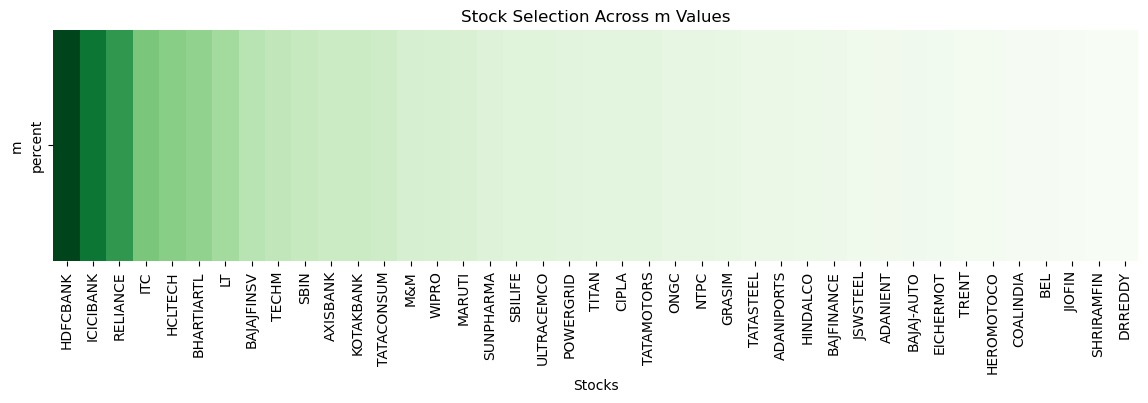

In [138]:
import seaborn as sns

selection_df = pd.DataFrame(weights, index=data.columns[:-1]).T.reset_index(
    drop = True).T.rename(columns = {0:'percent'}).sort_values('percent', ascending= False).T

plt.figure(figsize=(14,3))
sns.heatmap(selection_df, cmap="Greens", cbar=False)
plt.title("Stock Selection Across m Values")
plt.xlabel("Stocks")
plt.ylabel("m")
plt.show()

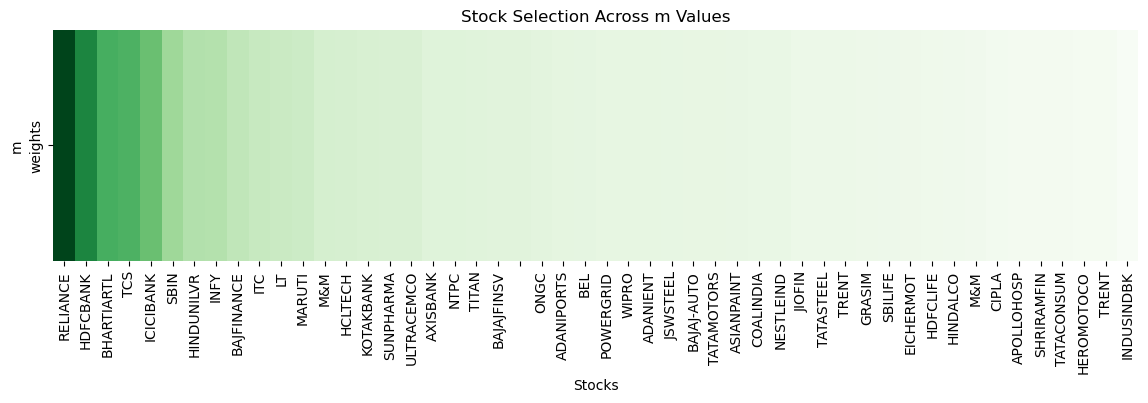

In [121]:
# selection_df = pd.DataFrame(weights, index=data.columns[:-1]).T

plt.figure(figsize=(14,3))
sns.heatmap(wts[['weights','Ticker']].set_index('Ticker').T, cmap="Greens", cbar=False)
plt.title("Stock Selection Across m Values")
plt.xlabel("Stocks")
plt.ylabel("m")
plt.show()